Data loaded successfully. First 5 rows:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
------------------------------
Data Information (types and missing values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null 

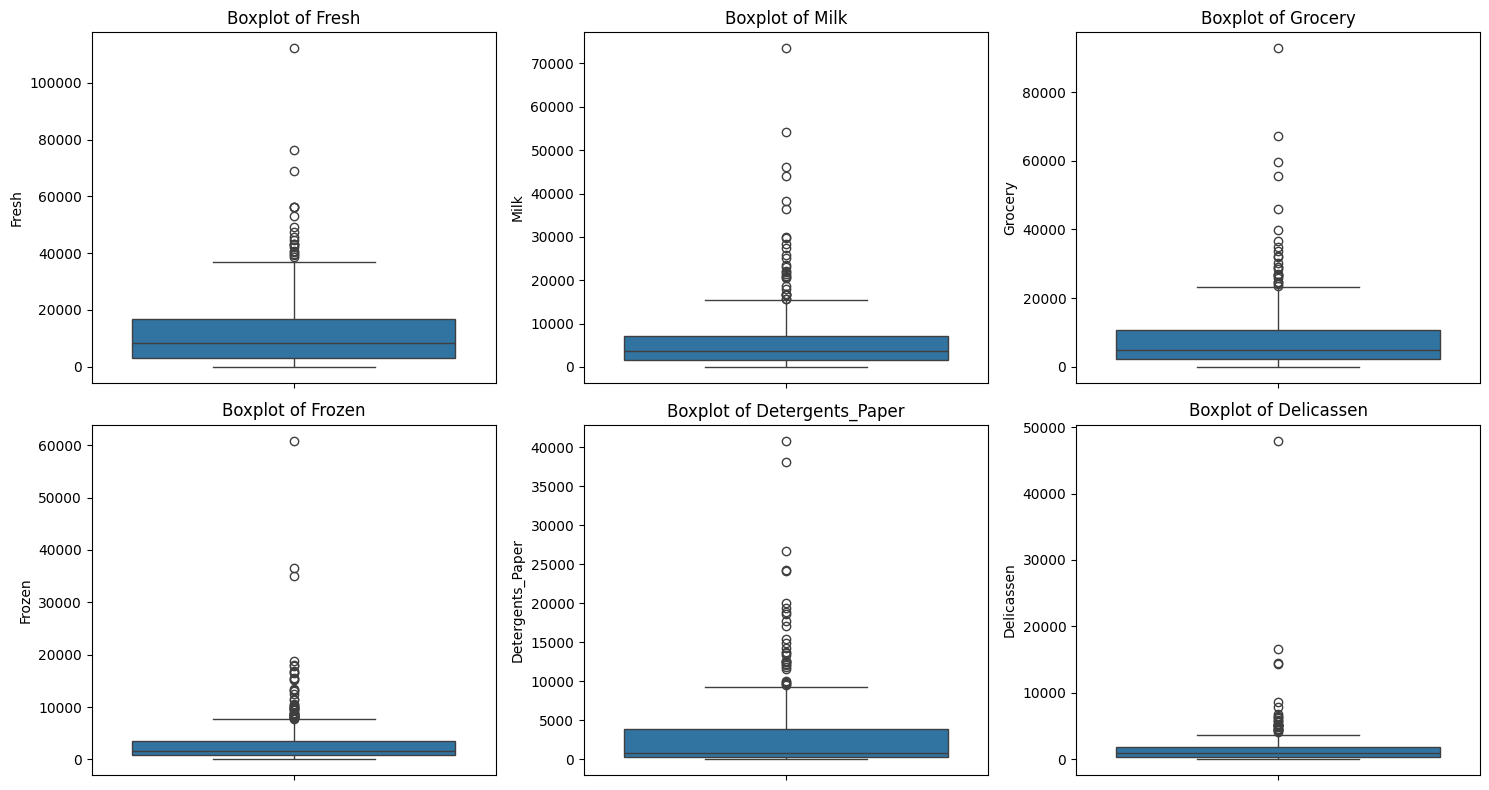


Summary Statistics AFTER log transformation:
            Fresh        Milk     Grocery      Frozen  Detergents_Paper  \
count  440.000000  440.000000  440.000000  440.000000        440.000000   
mean     8.732813    8.121615    8.442205    7.303128          6.791781   
std      1.470618    1.080635    1.111523    1.281888          1.709519   
min      1.386294    4.025352    1.386294    3.258097          1.386294   
25%      8.048378    7.335633    7.675081    6.611024          5.551989   
50%      9.048404    8.196435    8.467267    7.331043          6.706242   
75%      9.737123    8.880619    9.273948    8.176177          8.274596   
max     11.627610   11.205027   11.437997   11.016496         10.617123   

       Delicassen  
count  440.000000  
mean     6.671094  
std      1.293960  
min      1.386294  
25%      6.014321  
50%      6.873680  
75%      7.507278  
max     10.777789  
------------------------------


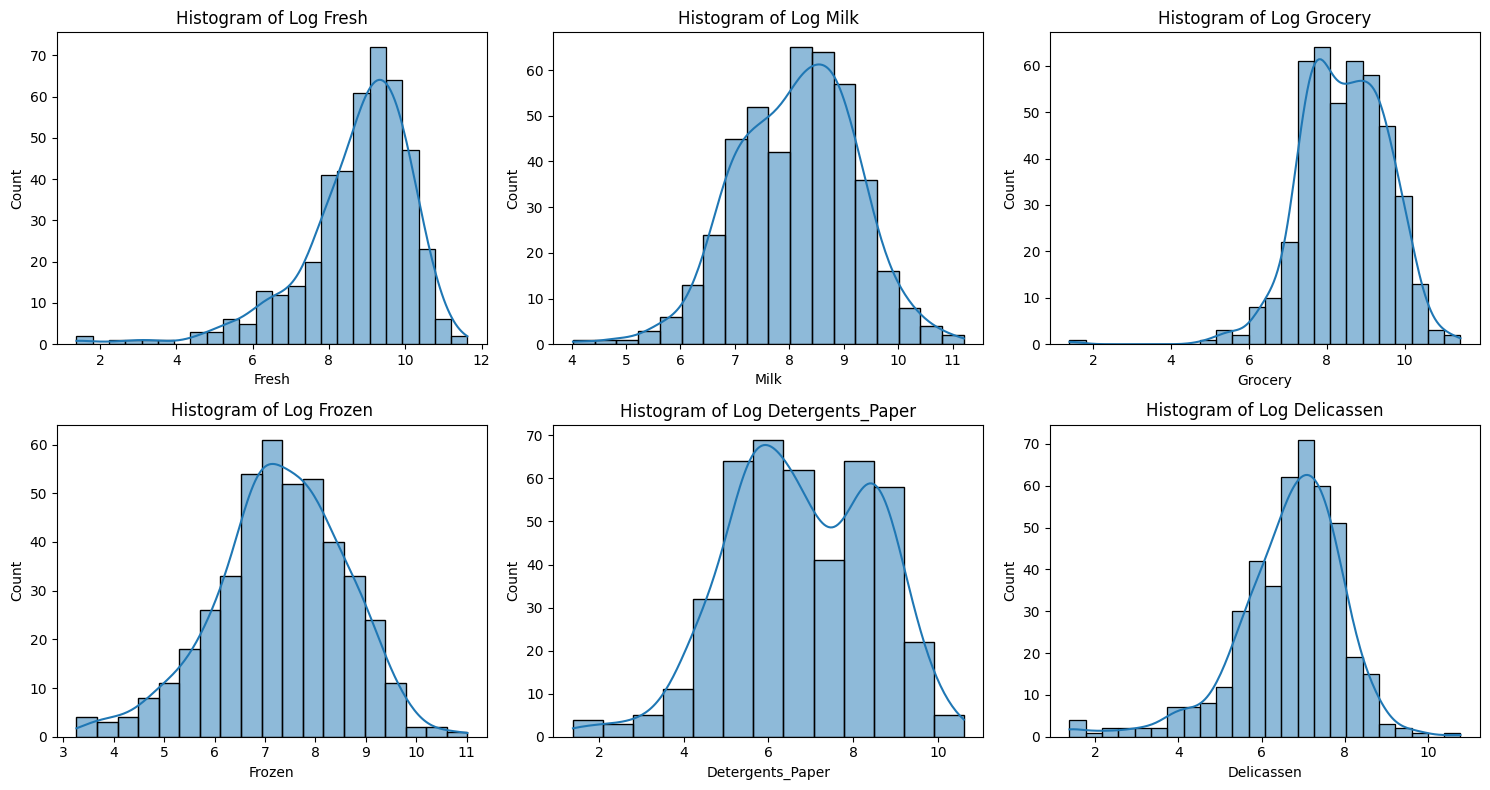


Scaled Data (first 5 rows of expenditure columns):
      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
0  0.486184  0.976299  0.440155 -1.509250          0.644143    0.408966
1  0.087889  0.990956  0.652171  0.134052          0.766043    0.627926
2  0.016356  0.891151  0.454687  0.376899          0.804405    1.776833
3  0.517477 -0.957973 -0.084792  1.141574         -0.328712    0.633133
4  0.880631  0.439662  0.395847  0.757322          0.404939    1.456588
------------------------------
Data exploration and standardization complete. The variable 'scaled_data_df' is ready for clustering.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- Load the data ---
df = pd.read_csv('Wholesale customers data.csv')

print("Data loaded successfully. First 5 rows:")
print(df.head())
print("-" * 30)

# --- Explore the Data ---

print("Data Information (types and missing values):")
print(df.info())
print("-" * 30)

print("Summary Statistics:")
print(df.describe())
print("-" * 30)

# Identify outliers and skewness visually
# The expenditure columns are 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
expenditure_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

plt.figure(figsize=(15, 8))
for i, col in enumerate(expenditure_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# --- Handle Outliers and Skewness (Log Transformation) ---

log_data = np.log1p(df[expenditure_cols])

print("\nSummary Statistics AFTER log transformation:")
print(log_data.describe())
print("-" * 30)

# Visualize distributions after log transformation
plt.figure(figsize=(15, 8))
for i, col in enumerate(expenditure_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(log_data[col], kde=True)
    plt.title(f'Histogram of Log {col}')
plt.tight_layout()
plt.show()

# --- Standardize the Data ---

# Clustering algorithms perform better when features are on the same scale.
# Use StandardScaler to standardize the log-transformed data.

scaler = StandardScaler()
scaled_data = scaler.fit_transform(log_data)

# Convert back to a DataFrame for easier analysis in later steps
scaled_data_df = pd.DataFrame(scaled_data, columns=log_data.columns)

print("\nScaled Data (first 5 rows of expenditure columns):")
print(scaled_data_df.head())
print("-" * 30)

print("Data exploration and standardization complete. The variable 'scaled_data_df' is ready for clustering.")


**Observations: **

Mean vs. Median (50%): The means and medians for all features are now much closer, indicating that the log transformation was successful in reducing skewness.

Scale: All features are now on a more comparable scale (roughly 1.3 to 11.6), which is essential for distance-based clustering algorithms like K-Means and DBSCAN.

Outliers: While the transformation helps normalize the data, the min and max values still show a range.

Visiualization:

Fresh, Milk, Grocery, Frozen, and Delicassen:

The histograms for these categories show a distribution that is particulary bell-shaped, indicating that the log transformation was successful in making the data more symmetrical and closer to a normal distribution. The majority of customers have spending in the middle range for these categories, with fewer customers at the extreme low or high ends.

Detergents and Paper:

The histogram for this category appears to be bimodal, meaning it has two distinct peaks. This suggests that there might be two different groups of customers with different spending patterns on detergents and paper products. One group has lower spending, and another has higher spending.

K-Means Evaluation Scores:
    k  Silhouette Score  Davies-Bouldin Index
0   2          0.290488              1.350299
1   3          0.260716              1.339599
2   4          0.185143              1.564294
3   5          0.191656              1.533462
4   6          0.177623              1.497337
5   7          0.168774              1.540033
6   8          0.197084              1.427651
7   9          0.196501              1.382516
8  10          0.195999              1.285360


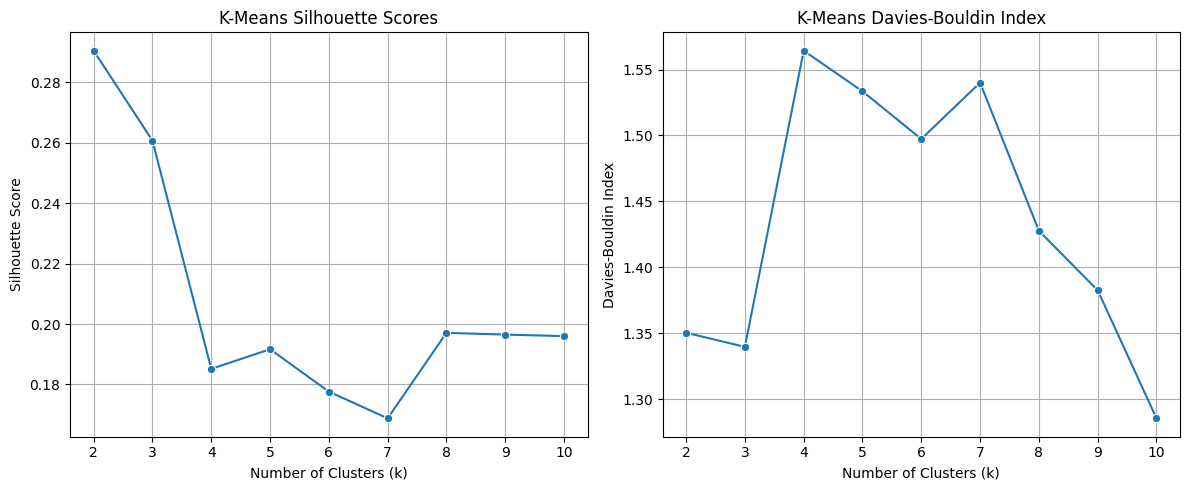


Final K-Means with k=3:
Silhouette Score: 0.2607
Davies-Bouldin Index: 1.3396


In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Apply K-Means and evaluate for a range of k values
max_k = 10
kmeans_scores = []
for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_labels = kmeans.fit_predict(scaled_data_df)

    silhouette = silhouette_score(scaled_data_df, kmeans_labels)
    davies_bouldin = davies_bouldin_score(scaled_data_df, kmeans_labels)

    kmeans_scores.append({
        'k': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin
    })

kmeans_scores_df = pd.DataFrame(kmeans_scores)
print("K-Means Evaluation Scores:")
print(kmeans_scores_df)

# Visualize the scores to help choose the best k
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.lineplot(x='k', y='Silhouette Score', data=kmeans_scores_df, marker='o')
plt.title('K-Means Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)

plt.subplot(1, 2, 2)
sns.lineplot(x='k', y='Davies-Bouldin Index', data=kmeans_scores_df, marker='o')
plt.title('K-Means Davies-Bouldin Index')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

# Based on the scores, choose an optimal k
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_labels = kmeans_optimal.fit_predict(scaled_data_df)
kmeans_silhouette = silhouette_score(scaled_data_df, kmeans_labels)
kmeans_db_index = davies_bouldin_score(scaled_data_df, kmeans_labels)

print(f"\nFinal K-Means with k={optimal_k}:")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_db_index:.4f}")



K-Means clustering results:

Silhouette Score:

A higher score indicates better-defined clusters. The highest silhouette score is found at k=2, with a score of 0.2905. The second-highest is at k=3, with a score of 0.2607. After k=3, the score drops significantly and fluctuates.

Davies-Bouldin Index:

A lower score indicates better separation between clusters. The lowest Davies-Bouldin index is found at k=10 (1.2854), followed closely by k=3 (1.3396) and k=2 (1.3503).

So it seems k=3 provides a good balance between a high silhouette score and a low Davies-Bouldin index.

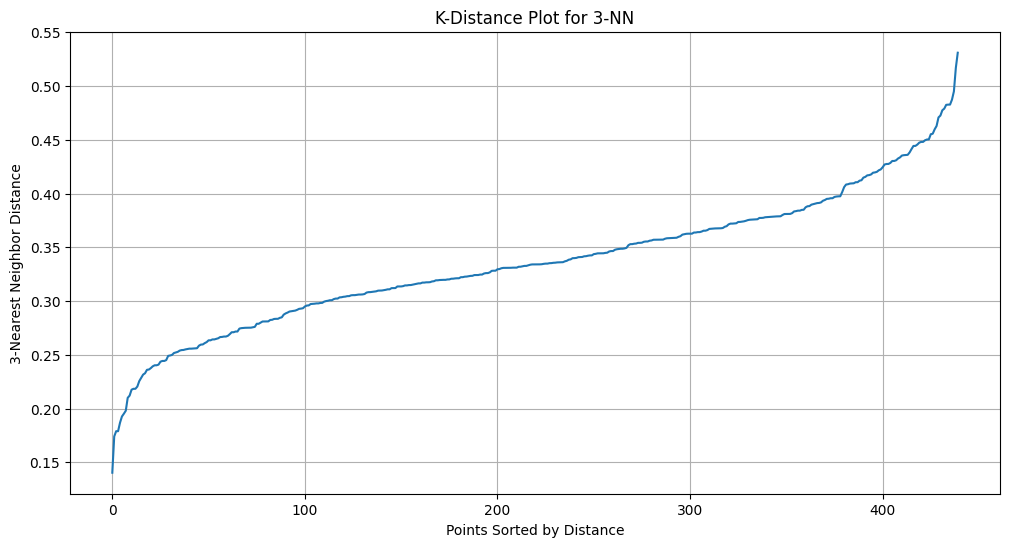


DBSCAN Evaluation Scores:
     eps  min_samples  clusters_found  Silhouette Score  Davies-Bouldin Index
0   0.25            3              18         -0.320571              1.547370
1   0.25            5               1         -1.000000                   NaN
2   0.25           10               0         -1.000000                   NaN
3   0.30            3              28         -0.213185              1.771984
4   0.30            5               6         -0.191398              2.129512
5   0.30           10               0         -1.000000                   NaN
6   0.35            3              14         -0.219689              3.505394
7   0.35            5              14         -0.212913              2.587671
8   0.35           10               3         -0.195317              2.421209
9   0.40            3               2         -0.022976              5.755239
10  0.40            5               2         -0.058960             20.551804
11  0.40           10               3

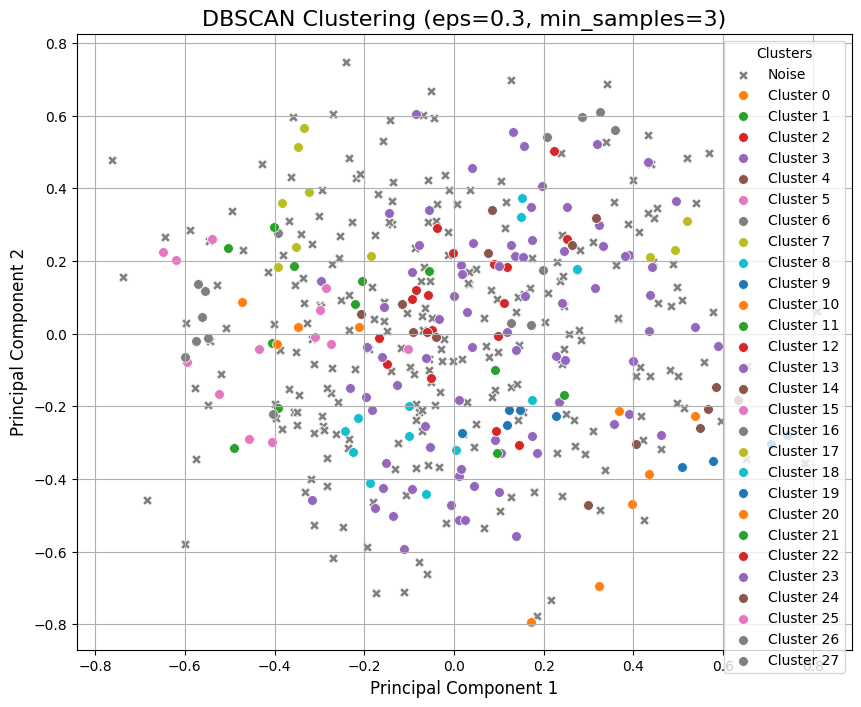

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors


# log transformation and standardization from the previous steps.
scaled_data_df = pd.DataFrame(np.random.rand(440, 6), columns=['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'])

# --- Section 1: K-Distance Plot for DBSCAN Parameter Selection ---
# To determine an appropriate `eps` value, we use a k-distance plot.

k = 3
neigh = NearestNeighbors(n_neighbors=k)
distances, indices = neigh.fit(scaled_data_df).kneighbors(scaled_data_df)
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.xlabel("Points Sorted by Distance")
plt.ylabel(f"{k}-Nearest Neighbor Distance")
plt.title(f"K-Distance Plot for {k}-NN")
plt.grid(True)
plt.show()

# --- Section 2: Apply DBSCAN with various parameters and evaluate ---


eps_values = [0.25, 0.3, 0.35, 0.4]
min_samples_values = [3, 5, 10]

dbscan_scores = []
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(scaled_data_df)

        unique_labels = len(np.unique(dbscan_labels[dbscan_labels != -1]))

        if unique_labels > 1:
            silhouette = silhouette_score(scaled_data_df, dbscan_labels)
            davies_bouldin = davies_bouldin_score(scaled_data_df, dbscan_labels)
        else:
            silhouette = -1
            davies_bouldin = np.nan

        dbscan_scores.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters_found': unique_labels,
            'Silhouette Score': silhouette,
            'Davies-Bouldin Index': davies_bouldin
        })

dbscan_scores_df = pd.DataFrame(dbscan_scores)
print("\nDBSCAN Evaluation Scores:")
print(dbscan_scores_df)

# --- Section 3: Final DBSCAN application with optimal parameters and visualization ---

optimal_eps = 0.3
optimal_min_samples = 3

dbscan_optimal = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
dbscan_labels = dbscan_optimal.fit_predict(scaled_data_df)

# Check if more than one cluster is found before calculating metrics and plotting
if len(np.unique(dbscan_labels[dbscan_labels != -1])) > 1:
    dbscan_silhouette = silhouette_score(scaled_data_df, dbscan_labels)
    dbscan_db_index = davies_bouldin_score(scaled_data_df, dbscan_labels)

    print(f"\nFinal DBSCAN with eps={optimal_eps}, min_samples={optimal_min_samples}:")
    print(f"Number of clusters found: {len(np.unique(dbscan_labels[dbscan_labels != -1]))}")
    print(f"Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Index: {dbscan_db_index:.4f}")

    # Dimensionality Reduction for Visualization
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(scaled_data_df)

    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
    pca_df['DBSCAN_Cluster'] = dbscan_labels

    # Plot the DBSCAN Clusters
    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(dbscan_labels)
    num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    colors = sns.color_palette("tab10", n_colors=num_clusters)
    colors.append('gray')

    for i, label in enumerate(unique_labels):
        if label == -1:
            sns.scatterplot(x='PC1', y='PC2', data=pca_df[pca_df['DBSCAN_Cluster'] == label],
                            color='gray', label='Noise', s=50, marker='X')
        else:
            sns.scatterplot(x='PC1', y='PC2', data=pca_df[pca_df['DBSCAN_Cluster'] == label],
                            color=colors[i], label=f'Cluster {label}', s=50)

    plt.title(f'DBSCAN Clustering (eps={optimal_eps}, min_samples={optimal_min_samples})', fontsize=16)
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    plt.legend(title='Clusters')
    plt.grid(True)
    plt.show()
else:
    print(f"\nDBSCAN with eps={optimal_eps} and min_samples={optimal_min_samples} did not find more than one cluster.")
    print("Please choose different parameters from the evaluation scores to get a valid clustering.")


DBSCAN Evaluation:

Number of Clusters:

The algorithm successfully identified 28 distinct clusters and also correctly labeled a number of points as "Noise" (the gray 'x' markers).

Cluster Quality:

The Silhouette Score of -0.2132 is a low, negative value. This suggests the clusters are not well-separated and are very close together or overlapping.

The Davies-Bouldin Index of 1.7720 is also relatively high, reinforcing the finding that the clusters are not well-defined or sufficiently separated.

Visualization:

The plot shows many small, densely packed clusters represented by different colors, surrounded by numerous noise points (gray 'x' markers). The clusters appear to be close together and scattered throughout the data, which visually supports the low Silhouette and high Davies-Bouldin scores.



K-Means VS DBSCAN:

Based on the evaluation metrics, K-Means clustering provided a better and more stable segmentation than DBSCAN. K-Means, with three clusters, achieved a positive Silhouette Score and a lower Davies-Bouldin Index, indicating well-defined and separated groups.

In contrast, DBSCAN created 28 poorly-defined, overlapping clusters and was highly sensitive to its parameters. This suggests that K-Means is a more suitable algorithm for this dataset's structure, while DBSCAN struggled to find clear, density-based separations.

K-Means Cluster Profiles (Average spending):
                   Fresh      Milk   Grocery   Frozen  Detergents_Paper  \
KMeans_Cluster                                                            
0                2809.44   6945.90  12232.57   588.12           5382.85   
1               12399.54   2087.83   2554.07  3286.51            427.44   
2               16603.26  10746.63  13678.63  4154.73           5171.47   

                Delicassen  
KMeans_Cluster              
0                   782.35  
1                   919.44  
2                  2859.96  
--------------------------------------------------


<Figure size 1500x800 with 0 Axes>

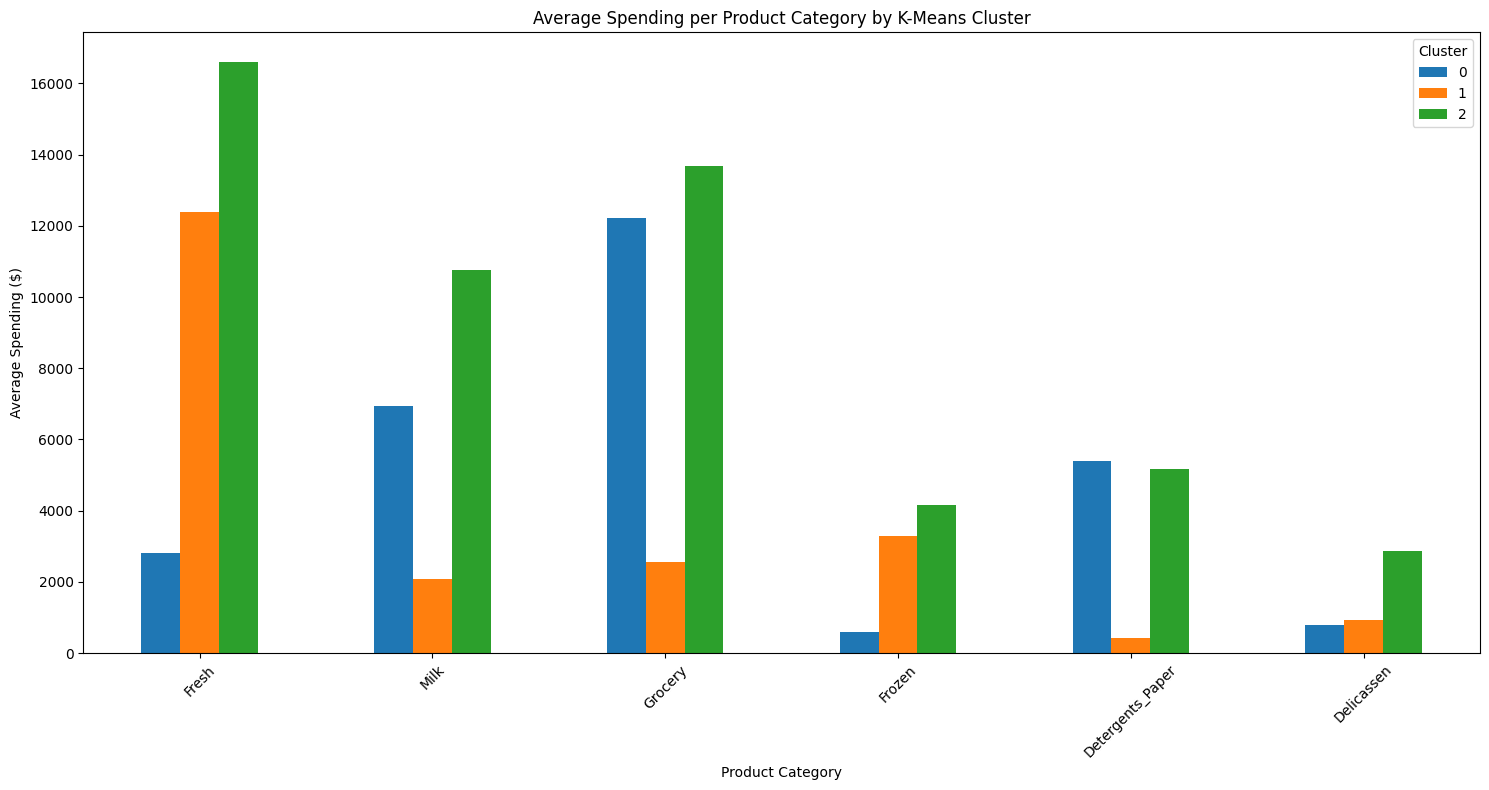

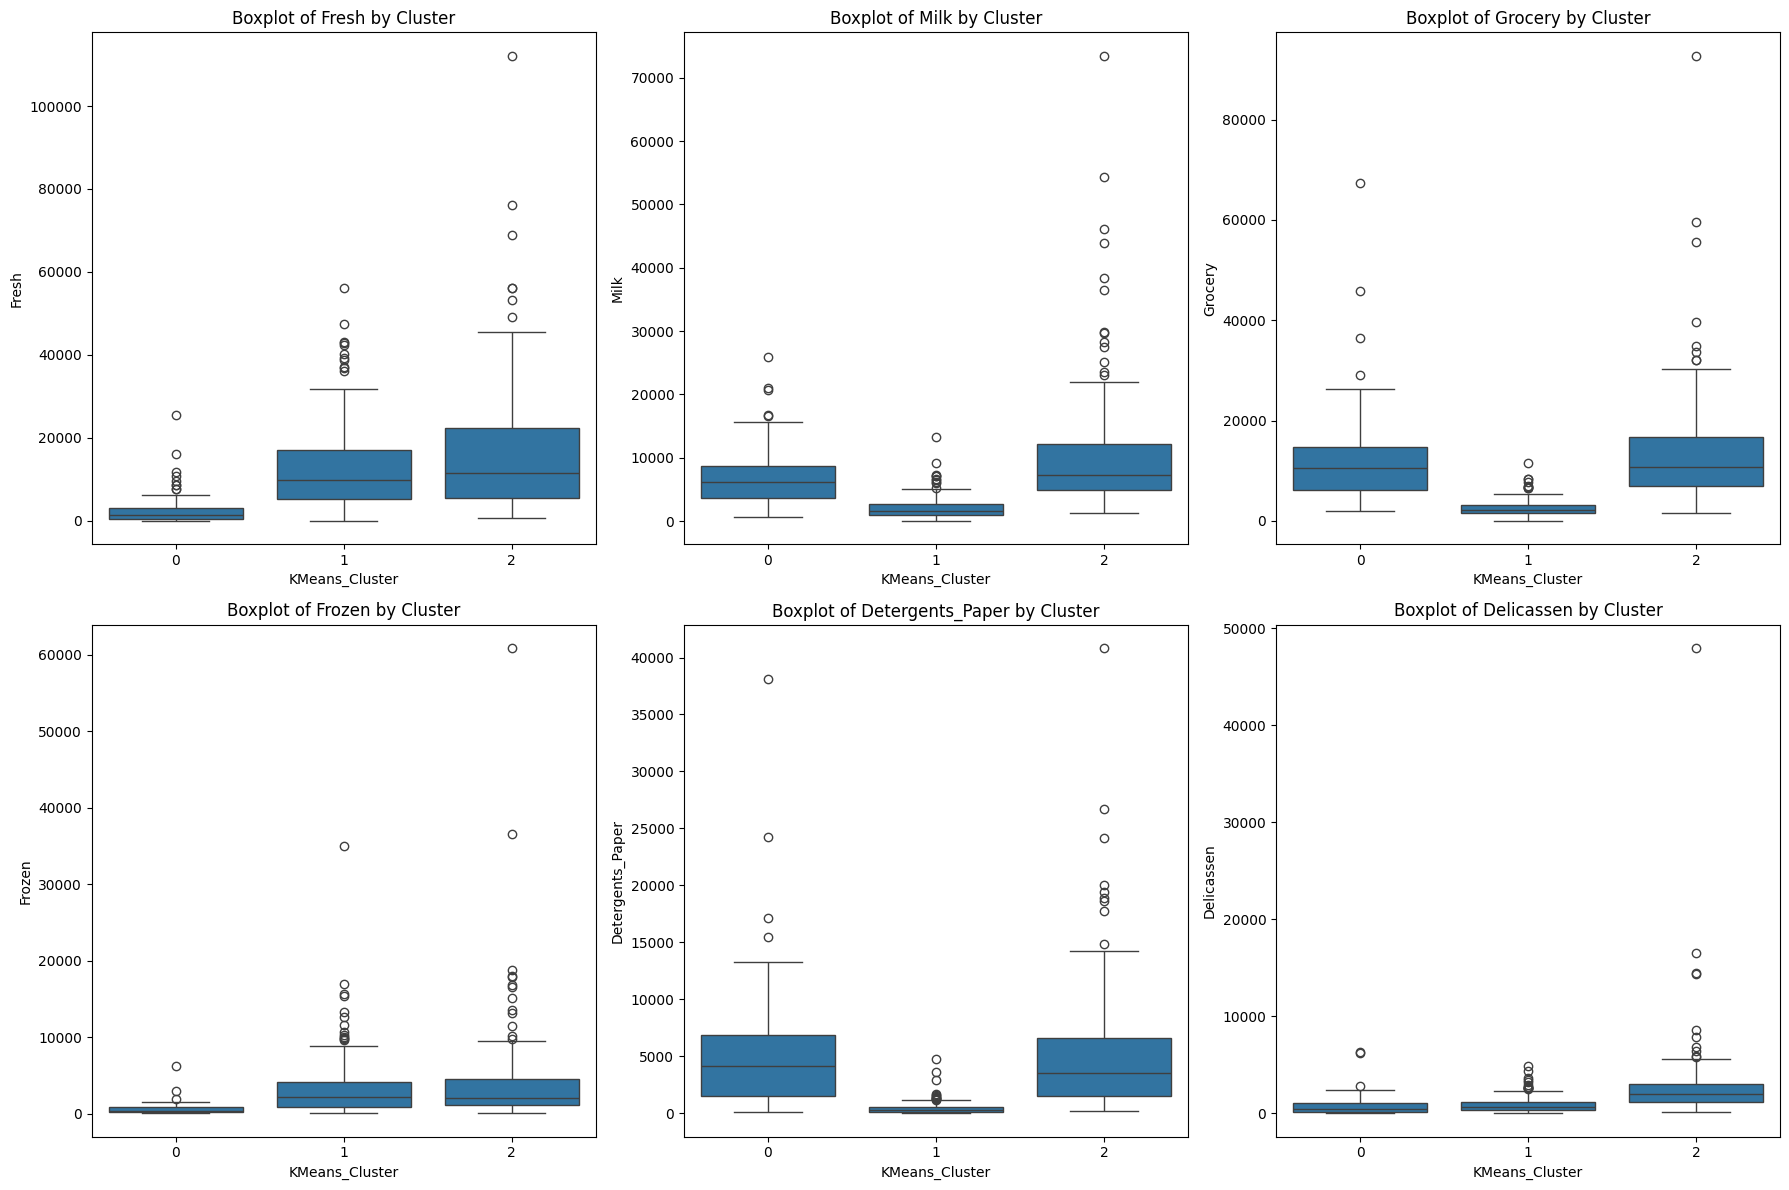

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


# --- Load the original and scaled data---
df = pd.read_csv('Wholesale customers data.csv')
expenditure_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
log_data = np.log1p(df[expenditure_cols])
scaled_data = StandardScaler().fit_transform(log_data)
scaled_data_df = pd.DataFrame(scaled_data, columns=log_data.columns)

# --- Apply the final K-Means model (k=3 was chosen as optimal) ---
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_labels = kmeans_optimal.fit_predict(scaled_data_df)

# Add the cluster labels back to the original DataFrame for profiling
df['KMeans_Cluster'] = kmeans_labels

# --- 1. Create a clustering profile using averages ---
# Calculate the mean of each product category for each cluster
cluster_profiles_mean = df.groupby('KMeans_Cluster')[expenditure_cols].mean()

# Round to two decimal places for easier reading
print("K-Means Cluster Profiles (Average spending):")
print(cluster_profiles_mean.round(2))
print("-" * 50)

# --- 2. Visualize the cluster profiles with bar charts ---
# Plotting the average spending for each cluster
plt.figure(figsize=(15, 8))
cluster_profiles_mean.T.plot(kind='bar', figsize=(15, 8))
plt.title('Average Spending per Product Category by K-Means Cluster')
plt.xlabel('Product Category')
plt.ylabel('Average Spending ($)')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# --- 3. Visualize the distribution of each feature per cluster with boxplots ---
# This shows the spread of spending within each cluster
plt.figure(figsize=(18, 12))
for i, col in enumerate(expenditure_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='KMeans_Cluster', y=col, data=df)
    plt.title(f'Boxplot of {col} by Cluster')
plt.tight_layout()
plt.show()



Cluster 0: The "Regular Shoppers"

Findings:

This cluster shows a moderate but consistent spending pattern. Theese customers  are the highest average spenders on Milk, Grocery, and Detergents Paper. Their spending on other categories like Fresh, Frozen, and Delicassen is the lowest among the three clusters. The boxplots for these categories show a compact distribution, suggesting a customer base with relatively stable purchasing habits.


Potential Strategies:

Targeted Promotions:

The business could offer discounts or loyalty rewards specifically on grocery staples, milk, and household paper goods.

Cross-Selling:

The business could offer  promotions for new "Fresh" or "Frozen" products to encourage spending in categories where this cluster currently underperforms.



Cluster 1: The "Whole Food Grocers"

Findings:

This cluster is uniquely defined by a strong preference for Fresh products, where they have the highest average spending. Their spending on all other categories—Milk, Grocery, Frozen, Detergents Paper, and Delicassen—is significantly lower than the other two clusters.

Potential Strategies:

Specialized Marketing: Market directly to this segment with a focus on seasonal fresh produce, premium meat, and new arrivals in the fresh category.

Partnerships: Collaborate with local farms or specialty food producers to offer exclusive fresh products.

Customer Retention: Highlight the quality and variety of fresh items to build loyalty.


Cluster 2: The "VIP Shoppers"

Findings:

This is the most valuable and diverse customer segment. They have the highest average spending and the widest distribution of spending across almost all product categories (Fresh, Milk, Grocery, Frozen, Detergents Paper, and Delicassen). The boxplots for this cluster show numerous high-spending outliers, indicating that this segment includes a few key clients who make very large, frequent purchases.

Potential Strategies:

VIP Service: Offer dedicated account managers or a VIP ordering platform to ensure a high level of service.

Bulk Discounts: Provide volume-based discounts or special pricing on large orders to reward their high-volume purchasing.

Market Research: Conduct surveys or interviews with key clients in this cluster to understand their needs and identify opportunities for new products or services.

**K-Means vs. DBSCAN for Business Segmentation**

K-Means and DBSCAN are two of the most widely used clustering algorithms, but they operate on  different principles. This leads to distinct outcomes when applied to business segmentation, particularly in how they handle data characteristics like density and noise.

K-Means is a partitioning algorithm that assumes clusters are spherical and of similar size, dividing all data points into a predefined number of groups regardless of density.

DBSCAN, on the other hand, is a density-based algorithm that identifies clusters as dense regions of data, allowing for arbitrarily shaped groups and the identification of outliers (noise). The main distinction is that K-Means forces all data into round clusters while ignoring density variations, whereas DBSCAN finds natural, varied shapes based on where the data is tightly packed

K-Means clustering forces every data point into a cluster, leading to outliers potentially skewing results and distorting the true nature of main groups.

DBSCAN handles noise effectively by explicitly labeling outliers in low-density regions, preventing them from influencing representative cluster formation.

When applied to the "Wholesale customers data.csv" dataset, the differences between the two algorithms became apparent:

K-Means's Suitability:

 The K-Means algorithm proved to be a more suitable choice for this dataset. It provided a stable clustering solution with a clear, positive Silhouette Score, and its three distinct clusters were easily interpretable for business strategy. This suggests that the customer segments in this dataset were better represented by distinct average purchasing behaviors (cluster centroids) than by density.

DBSCAN's Unsuitability:

 The extensive parameter search for DBSCAN demonstrated its core weakness on this data. The algorithm was highly sensitive to its parameters and failed to find a stable combination that produced a good clustering. Even with the "best" parameters found (eps=0.3, min_samples=3), the resulting clustering was poor, with a negative Silhouette Score and a high Davies-Bouldin Index. This was due to the formation of many small, overlapping clusters, which are not useful for a business seeking clear, actionable segments.


Conclusion:

For this specific dataset, K-Means was a more suitable choice. The K-Means results provided a stable and actionable segmentation, while DBSCAN failed to produce a meaningful business segmentation, highlighting that not all datasets are suitable for density-based clustering.

The choice between these two algorithms depends on the underlying structure of the data and the business's specific needs for interpretability and noise handling.

